In [8]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

Load Data

In [9]:
book_data = pd.read_csv('book_reviews_sample.csv')
book_data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [22]:
book_data['reviewText_clean'] = book_data['reviewText'].str.lower().apply(lambda x: re.sub(r"[^\w\s]", "", x))
book_data['reviewText_clean'][2]

'good thing that this is a free story i read it a few years ago and it is not worth the time'

VADER SENTIMENT

In [35]:
sentiment = SentimentIntensityAnalyzer()
book_data['vader_sentiment_score'] = book_data['reviewText_clean'].apply(lambda x: sentiment.polarity_scores(x)['compound'])

bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

book_data['vader_sentiment_label'] = pd.cut(book_data['vader_sentiment_score'], bins=bins, labels=names)
book_data.head(15)

,index,reviewText,rating,reviewText_clean,vader_sentiment_score,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative
5,7277,"Great book packed full with fast cars , crazy ...",4,great book packed full with fast cars crazy h...,0.7269,positive
6,9781,I enjoyed the reader's digest very much. If I ...,4,i enjoyed the readers digest very much if i co...,0.5106,positive
7,4583,This series has been good and I look forward t...,5,this series has been good and i look forward t...,0.7906,positive
8,9797,I just could not get into this book.I all ways...,1,i just could not get into this booki all ways ...,0.0000,neutral
9,895,it was good to see where Dan and Elle was. And...,4,it was good to see where dan and elle was and ...,0.8107,positive


<Axes: xlabel='vader_sentiment_label'>

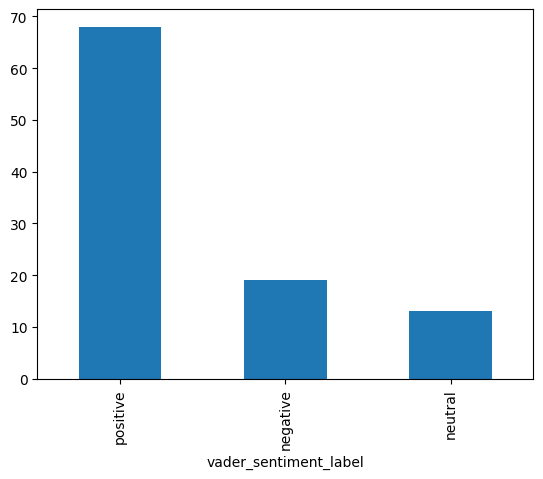

In [42]:
book_data['vader_sentiment_label'].value_counts().plot.bar()

Pre-Trained Transformer

In [44]:
sentiment_pipeline = pipeline('sentiment-analysis')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


[['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['POSITIVE'], ['POSITIVE'], ['POSITIVE'], ['NEGATIVE'], ['NEGATIVE'], ['POSITIVE'], ['NEGATIVE'], ['POS

<Axes: ylabel='transformer_sentiment_anaylsis'>

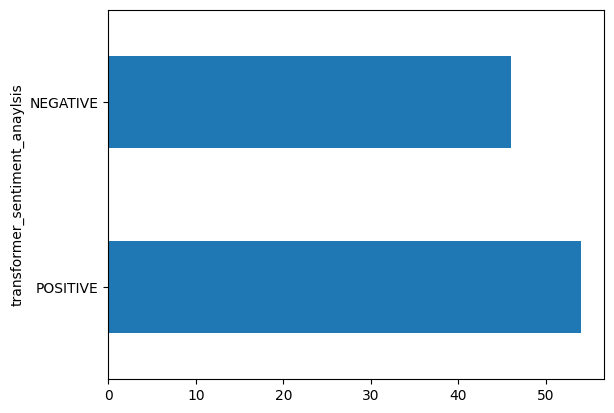

In [63]:
transformer_labels = []

for label in book_data['reviewText_clean'].values:
    sentiment = sentiment_pipeline(label)
    sentiment_label = [sent['label'] for sent in sentiment]
    transformer_labels.append(sentiment_label)

print(transformer_labels)

book_data['transformer_sentiment_anaylsis'] = pd.DataFrame(transformer_labels)
book_data.head()
book_data['transformer_sentiment_anaylsis'].value_counts().plot.barh()